In [1]:
import argparse
from copy import deepcopy
from typing import Tuple, Union, List

import numpy as np
from batchgenerators.augmentations.utils import resize_segmentation
from nnunet.inference.segmentation_export import save_segmentation_nifti_from_softmax, save_segmentation_nifti
from batchgenerators.utilities.file_and_folder_operations import *
import sys
if 'win' in sys.platform:
    #fix for windows platform
    import pathos
    Process = pathos.helpers.mp.Process
    Queue = pathos.helpers.mp.Queue
else:
    from multiprocessing import Process, Queue
import torch
import SimpleITK as sitk
import shutil
from multiprocessing import Pool
from nnunet.postprocessing.connected_components import load_remove_save, load_postprocessing
from nnunet.training.model_restore import load_model_and_checkpoint_files
from nnunet.training.network_training.nnUNetTrainer import nnUNetTrainer
from nnunet.utilities.one_hot_encoding import to_one_hot



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

nnUNet_raw_data_base is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
RESULTS_FOLDER is not defined and nnU-Net cannot be used for training or inference. If this is not in

In [2]:
def check_input_folder_and_return_caseIDs(input_folder, expected_num_modalities):
    print("This model expects %d input modalities for each image" % expected_num_modalities)
    files = subfiles(input_folder, suffix=".nii.gz", join=False, sort=True)

    maybe_case_ids = np.unique([i[:-12] for i in files])

    remaining = deepcopy(files)
    missing = []

    assert len(files) > 0, "input folder did not contain any images (expected to find .nii.gz file endings)"

    # now check if all required files are present and that no unexpected files are remaining
    for c in maybe_case_ids:
        for n in range(expected_num_modalities):
            expected_output_file = c + "_%04.0d.nii.gz" % n
            if not isfile(join(input_folder, expected_output_file)):
                missing.append(expected_output_file)
            else:
                remaining.remove(expected_output_file)

    print("Found %d unique case ids, here are some examples:" % len(maybe_case_ids),
          np.random.choice(maybe_case_ids, min(len(maybe_case_ids), 10)))
    print("If they don't look right, make sure to double check your filenames. They must end with _0000.nii.gz etc")

    if len(remaining) > 0:
        print("found %d unexpected remaining files in the folder. Here are some examples:" % len(remaining),
              np.random.choice(remaining, min(len(remaining), 10)))

    if len(missing) > 0:
        print("Some files are missing:")
        print(missing)
        raise RuntimeError("missing files in input_folder")

    return maybe_case_ids

In [4]:
ModelDir = "C:/Single-Centre-Gamma-Knife-(SC-GK)-models/ceT1/nnUNet/3d_fullres/Task700_VS/nnUNetTrainerV2__nnUNetPlansv2.1"

In [5]:
input_folder = "C:/example_input_images/ceT1"

In [6]:
output_folder = "C:/Users/Rishabh/Documents/nnUNet/output_folder"

In [7]:
shutil.copy(join(ModelDir, 'plans.pkl'), output_folder)

'C:/Users/Rishabh/Documents/nnUNet/output_folder\\plans.pkl'

In [8]:
print(os.listdir(ModelDir))

['fold_0', 'fold_0.zip', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'plans.pkl', 'postprocessing.json']


In [9]:
expected_num_modalities = load_pickle(join(ModelDir, "plans.pkl"))['num_modalities']

In [10]:
expected_num_modalities

1

In [11]:
case_ids = check_input_folder_and_return_caseIDs(input_folder, expected_num_modalities)

This model expects 1 input modalities for each image
Found 1 unique case ids, here are some examples: ['vs_gk']
If they don't look right, make sure to double check your filenames. They must end with _0000.nii.gz etc


In [12]:
case_ids

array(['vs_gk'], dtype='<U5')

In [13]:
output_files = [join(output_folder, i + ".nii.gz") for i in case_ids]

In [14]:
output_files

['C:/Users/Rishabh/Documents/nnUNet/output_folder\\vs_gk.nii.gz']

In [15]:
all_files = subfiles(input_folder, suffix=".nii.gz", join=False, sort=True)

In [16]:
all_files

['vs_gk_0000.nii.gz']

In [17]:
list_of_lists = [[join(input_folder, i) for i in all_files if i[:len(j)].startswith(j) and
                  len(i) == (len(j) + 12)] for j in case_ids]

In [18]:
list_of_lists

[['C:/example_input_images/ceT1\\vs_gk_0000.nii.gz']]

In [21]:
cleaned_output_files = []
for o in output_files:
    dr, f = os.path.split(o)
    if len(dr) > 0:
        maybe_mkdir_p(dr)
    if not f.endswith(".nii.gz"):
        f, _ = os.path.splitext(f)
        f = f + ".nii.gz"
    cleaned_output_files.append(join(dr, f))

In [22]:
cleaned_output_files

['C:/Users/Rishabh/Documents/nnUNet/output_folder\\vs_gk.nii.gz']

In [23]:
print("number of cases:", len(list_of_lists))
# if save_npz=True then we should also check for missing npz files
not_done_idx = [i for i, j in enumerate(cleaned_output_files) if (not isfile(j)) or (save_npz and not isfile(j[:-7] + '.npz'))]

cleaned_output_files = [cleaned_output_files[i] for i in not_done_idx]
list_of_lists = [list_of_lists[i] for i in not_done_idx]

print("number of cases that still need to be predicted:", len(cleaned_output_files))

number of cases: 1


NameError: name 'save_npz' is not defined

In [24]:
print("emptying cuda cache")
torch.cuda.empty_cache()

emptying cuda cache


In [25]:
mixed_precision=True
# mixed_precision = False

checkpoint_name: str = "model_final_checkpoint"
folds = [0]
segmentation_export_kwargs = None

In [26]:
trainer, params = load_model_and_checkpoint_files(ModelDir, folds, mixed_precision=mixed_precision,
                                                  checkpoint_name=checkpoint_name)

2025-01-22 12:10:28.563159: Using dummy2d data augmentation
using the following model files:  ['C:/Single-Centre-Gamma-Knife-(SC-GK)-models/ceT1/nnUNet/3d_fullres/Task700_VS/nnUNetTrainerV2__nnUNetPlansv2.1\\fold_0\\model_final_checkpoint.model']


C:\Users\Rishabh\Documents\nnUNet\nnunet\training\model_restore.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_params = [torch.load(i, map_location=torch.device('

In [27]:
trainer

In [28]:
if segmentation_export_kwargs is None:
    if 'segmentation_export_params' in trainer.plans.keys():
        force_separate_z = trainer.plans['segmentation_export_params']['force_separate_z']
        interpolation_order = trainer.plans['segmentation_export_params']['interpolation_order']
        interpolation_order_z = trainer.plans['segmentation_export_params']['interpolation_order_z']
    else:
        force_separate_z = None
        interpolation_order = 1
        interpolation_order_z = 0
else:
    force_separate_z = segmentation_export_kwargs['force_separate_z']
    interpolation_order = segmentation_export_kwargs['interpolation_order']
    interpolation_order_z = segmentation_export_kwargs['interpolation_order_z']

In [29]:
print(force_separate_z)
print(interpolation_order)
print(interpolation_order_z)

None
1
0


In [31]:
errors_in = []
for i, l in enumerate(list_of_lists):
    print(i," ",l)
    output_file = cleaned_output_files[i]
    d, _, dct = trainer.preprocess_patient(l)
    # print(dct)
  

0   ['C:/example_input_images/ceT1\\vs_gk_0000.nii.gz']
using preprocessor GenericPreprocessor
before crop: (1, 81, 488, 416) after crop: (1, 81, 488, 416) spacing: [1.5        0.41015625 0.41015625] 

no resampling necessary
no resampling necessary
before: {'spacing': array([1.5       , 0.41015625, 0.41015625]), 'spacing_transposed': array([1.5       , 0.41015625, 0.41015625]), 'data.shape (data is transposed)': (1, 81, 488, 416)} 
after:  {'spacing': array([1.5       , 0.41015625, 0.41015625]), 'data.shape (data is resampled)': (1, 81, 488, 416)} 



In [32]:
def preprocess_save_to_queue(preprocess_fn, q, list_of_lists, output_files, segs_from_prev_stage, classes,
                             transpose_forward):
    # suppress output
    # sys.stdout = open(os.devnull, 'w')

    errors_in = []
    for i, l in enumerate(list_of_lists):
        try:
            output_file = output_files[i]
            print("preprocessing", output_file)
            d, _, dct = preprocess_fn(l)
            # print(output_file, dct)
            if segs_from_prev_stage[i] is not None:
                assert isfile(segs_from_prev_stage[i]) and segs_from_prev_stage[i].endswith(
                    ".nii.gz"), "segs_from_prev_stage" \
                                " must point to a " \
                                "segmentation file"
                seg_prev = sitk.GetArrayFromImage(sitk.ReadImage(segs_from_prev_stage[i]))
                # check to see if shapes match
                img = sitk.GetArrayFromImage(sitk.ReadImage(l[0]))
                assert all([i == j for i, j in zip(seg_prev.shape, img.shape)]), "image and segmentation from previous " \
                                                                                 "stage don't have the same pixel array " \
                                                                                 "shape! image: %s, seg_prev: %s" % \
                                                                                 (l[0], segs_from_prev_stage[i])
                seg_prev = seg_prev.transpose(transpose_forward)
                seg_reshaped = resize_segmentation(seg_prev, d.shape[1:], order=1)
                seg_reshaped = to_one_hot(seg_reshaped, classes)
                d = np.vstack((d, seg_reshaped)).astype(np.float32)
            """There is a problem with python process communication that prevents us from communicating objects 
            larger than 2 GB between processes (basically when the length of the pickle string that will be sent is 
            communicated by the multiprocessing.Pipe object then the placeholder (I think) does not allow for long 
            enough strings (lol). This could be fixed by changing i to l (for long) but that would require manually 
            patching system python code. We circumvent that problem here by saving softmax_pred to a npy file that will 
            then be read (and finally deleted) by the Process. save_segmentation_nifti_from_softmax can take either 
            filename or np.ndarray and will handle this automatically"""
            print(d.shape)
            if np.prod(d.shape) > (2e9 / 4 * 0.85):  # *0.85 just to be save, 4 because float32 is 4 bytes
                print(
                    "This output is too large for python process-process communication. "
                    "Saving output temporarily to disk")
                np.save(output_file[:-7] + ".npy", d)
                d = output_file[:-7] + ".npy"
            q.put((output_file, (d, dct)))
        except KeyboardInterrupt:
            raise KeyboardInterrupt
        except Exception as e:
            print("error in", l)
            print(e)
    q.put("end")
    if len(errors_in) > 0:
        print("There were some errors in the following cases:", errors_in)
        print("These cases were ignored.")
    else:
        print("This worker has ended successfully, no errors to report")
    # restore output
    # sys.stdout = sys.__stdout__

In [33]:
classes = list(range(1, trainer.num_classes))
transpose_forward = trainer.plans['transpose_forward']
output_files = cleaned_output_files
segs_from_prev_stage: dict = None

In [34]:
print(list_of_lists)

[['C:/example_input_images/ceT1\\vs_gk_0000.nii.gz']]


In [35]:
errors_in = []
for i, l in enumerate(list_of_lists):
    try:
        
        output_file = output_files[i]
        print("preprocessing", output_file)
        
        d, _, dct =trainer.preprocess_patient(l)
        print(output_file, dct)
        print(d.shape)
        if np.prod(d.shape) > (2e9 / 4 * 0.85):  # *0.85 just to be save, 4 because float32 is 4 bytes
            print(
                "This output is too large for python process-process communication. "
                "Saving output temporarily to disk")
            np.save(output_file[:-7] + ".npy", d)
            d = output_file[:-7] + ".npy"
    except KeyboardInterrupt:
        raise KeyboardInterrupt
    except Exception as e:
        print("error in", l)
        print(e)

preprocessing C:/Users/Rishabh/Documents/nnUNet/output_folder\vs_gk.nii.gz
using preprocessor GenericPreprocessor
before crop: (1, 81, 488, 416) after crop: (1, 81, 488, 416) spacing: [1.5        0.41015625 0.41015625] 

no resampling necessary
no resampling necessary
before: {'spacing': array([1.5       , 0.41015625, 0.41015625]), 'spacing_transposed': array([1.5       , 0.41015625, 0.41015625]), 'data.shape (data is transposed)': (1, 81, 488, 416)} 
after:  {'spacing': array([1.5       , 0.41015625, 0.41015625]), 'data.shape (data is resampled)': (1, 81, 488, 416)} 

C:/Users/Rishabh/Documents/nnUNet/output_folder\vs_gk.nii.gz OrderedDict([('original_size_of_raw_data', array([ 81, 488, 416])), ('original_spacing', array([1.5       , 0.41015625, 0.41015625])), ('list_of_data_files', ['C:/example_input_images/ceT1\\vs_gk_0000.nii.gz']), ('seg_file', None), ('itk_origin', (-83.76821899414062, -118.1525650024414, -78.50067138671875)), ('itk_spacing', (0.41015625, 0.41015625, 1.5)), ('itk

In [36]:
output_file[:-7] + ".npy"

'C:/Users/Rishabh/Documents/nnUNet/output_folder\\vs_gk.npy'

In [37]:
print("predicting", output_file)
trainer.load_checkpoint_ram(params[0], False)

predicting C:/Users/Rishabh/Documents/nnUNet/output_folder\vs_gk.nii.gz


C:\Users\Rishabh\Documents\nnUNet\nnunet\training\network_training\network_trainer.py:404: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_grad_scaler = GradScaler()


In [38]:
do_tta = True
step_size=0.5
all_in_gpu = True

In [39]:
softmax = trainer.predict_preprocessed_data_return_seg_and_softmax(
    d, do_mirroring=do_tta, mirror_axes=trainer.data_aug_params['mirror_axes'], use_sliding_window=True,
    step_size=step_size, use_gaussian=True, all_in_gpu=all_in_gpu,
    mixed_precision=mixed_precision)[1]

debug: mirroring True mirror_axes (0, 1, 2)
step_size: 0.5
do mirror: True
data shape: (1, 81, 488, 416)
patch size: [ 56 224 160]
steps (x, y, and z): [[0, 25], [0, 88, 176, 264], [0, 64, 128, 192, 256]]
number of tiles: 40
computing Gaussian


C:\Users\Rishabh\Documents\nnUNet\nnunet\network_architecture\neural_network.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with context():


done


KeyboardInterrupt: 

In [36]:
for p in params[1:]:
    trainer.load_checkpoint_ram(p, False)
    softmax += trainer.predict_preprocessed_data_return_seg_and_softmax(
        d, do_mirroring=do_tta, mirror_axes=trainer.data_aug_params['mirror_axes'], use_sliding_window=True,
        step_size=step_size, use_gaussian=True, all_in_gpu=all_in_gpu,
        mixed_precision=mixed_precision)[1]

In [37]:
if len(params) > 1:
    softmax /= len(params)

In [38]:
transpose_forward = trainer.plans.get('transpose_forward')
if transpose_forward is not None:
    transpose_backward = trainer.plans.get('transpose_backward')
    softmax = softmax.transpose([0] + [i + 1 for i in transpose_backward])

In [39]:
if hasattr(trainer, 'regions_class_order'):
    region_class_order = trainer.regions_class_order
else:
    region_class_order = None

In [40]:
bytes_per_voxel = 4
if all_in_gpu:
    bytes_per_voxel = 2  # if all_in_gpu then the return value is half (float16)

In [41]:
np.save(output_file[:-7] + ".npy", softmax)

In [43]:
npz_file = None

In [44]:
            # softmax = output_filename[:-7] + ".npy"
save_segmentation_nifti_from_softmax(softmax, output_file, dct, interpolation_order, region_class_order,
                                    None, None,
                                    npz_file, None, force_separate_z, interpolation_order_z)

force_separate_z: None interpolation order: 1
no resampling necessary


In [42]:
output_file

'C:/Users/Rishabh/Documents/nnUNet/output_folder\\vs_gk.nii.gz'

In [46]:
disable_postprocessing = False

In [54]:
if not disable_postprocessing:
    # results = []
    pp_file = join(ModelDir, "postprocessing.json")
    if isfile(pp_file):
        print("postprocessing...")
        shutil.copy(pp_file, os.path.abspath(os.path.dirname(output_file)))
        # for_which_classes stores for which of the classes everything but the largest connected component needs to be
        # removed
        for_which_classes, min_valid_obj_size = load_postprocessing(pp_file)
        largest_removed, kept_size = load_remove_save(output_file, output_file, for_which_classes , min_valid_obj_size)
    else:
        print("WARNING! Cannot run postprocessing because the postprocessing file is missing. Make sure to run "
              "consolidate_folds in the output folder of the model first!\nThe folder you need to run this in is "
              "%s" % ModelDir)

postprocessing...


In [51]:
for_which_classes

[[1]]

In [52]:
min_valid_obj_size

In [57]:
predictions = "C:/Users/Rishabh/Documents/nnUNet/output_folder/vs_gk.nii.gz"

In [56]:
print(os.listdir(predictions))

['plans.pkl', 'postprocessing.json', 'vs_gk.nii.gz', 'vs_gk.npy']


In [59]:
import nibabel as nib
import numpy as np

# Load the .nii.gz file
file_path = "C:/Users/Rishabh/Documents/nnUNet/output_folder/vs_gk.nii.gz"
nii_img = nib.load(file_path)

# Get the data as a NumPy array
data = nii_img.get_fdata()

# Print basic information
print("Shape of the data:", data.shape)
print("Data type:", data.dtype)

# If you want metadata
print("Affine matrix:\n", nii_img.affine)
print("Header information:\n", nii_img.header)


Shape of the data: (416, 488, 81)
Data type: float64
Affine matrix:
 [[ -0.41015625   0.           0.          83.76821899]
 [  0.          -0.41015625   0.         118.152565  ]
 [  0.           0.           1.5        -78.50067139]
 [  0.           0.           0.           1.        ]]
Header information:
 <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 416 488  81   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1.         0.41015625 0.41015625 1.5        0.         0.
 0.         0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max    

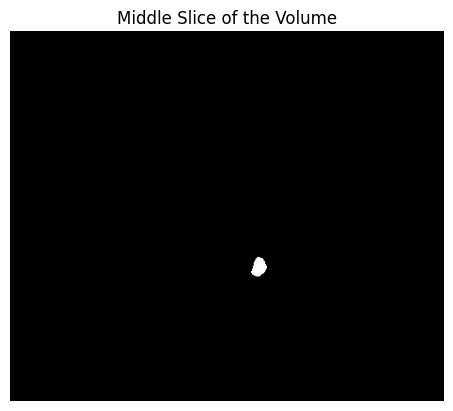

In [65]:
import matplotlib.pyplot as plt

# Display a slice (e.g., along the z-axis)
plt.imshow(data[:, :, data.shape[2] // 5], cmap="gray")
plt.title("Middle Slice of the Volume")
plt.axis("off")
plt.show()

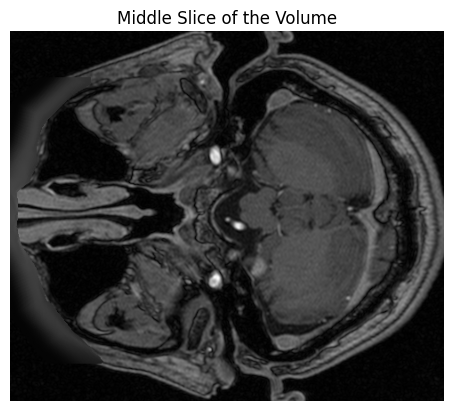

In [69]:
import matplotlib.pyplot as plt

# Display a slice (e.g., along the z-axis)
plt.imshow(data[:, :, data.shape[2] // 5], cmap="gray")
plt.title("Middle Slice of the Volume")
plt.axis("off")
plt.show()

In [63]:
%matplotlib inline


In [67]:
originalImage = "C:/example_input_images/ceT1/vs_gk_0000.nii.gz"

In [68]:
import nibabel as nib
import numpy as np

# Load the .nii.gz file
file_path = "C:/example_input_images/ceT1/vs_gk_0000.nii.gz"
nii_img = nib.load(file_path)

# Get the data as a NumPy array
data = nii_img.get_fdata()

# Print basic information
print("Shape of the data:", data.shape)
print("Data type:", data.dtype)

# If you want metadata
print("Affine matrix:\n", nii_img.affine)
print("Header information:\n", nii_img.header)

Shape of the data: (416, 488, 81)
Data type: float64
Affine matrix:
 [[ -0.41015625   0.           0.          83.76821899]
 [  0.          -0.41015625   0.         118.152565  ]
 [  0.           0.           1.5        -78.50067139]
 [  0.           0.           0.           1.        ]]
Header information:
 <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 416 488  81   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.41015625 0.41015625 1.5        1.         1.
 1.         1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max   

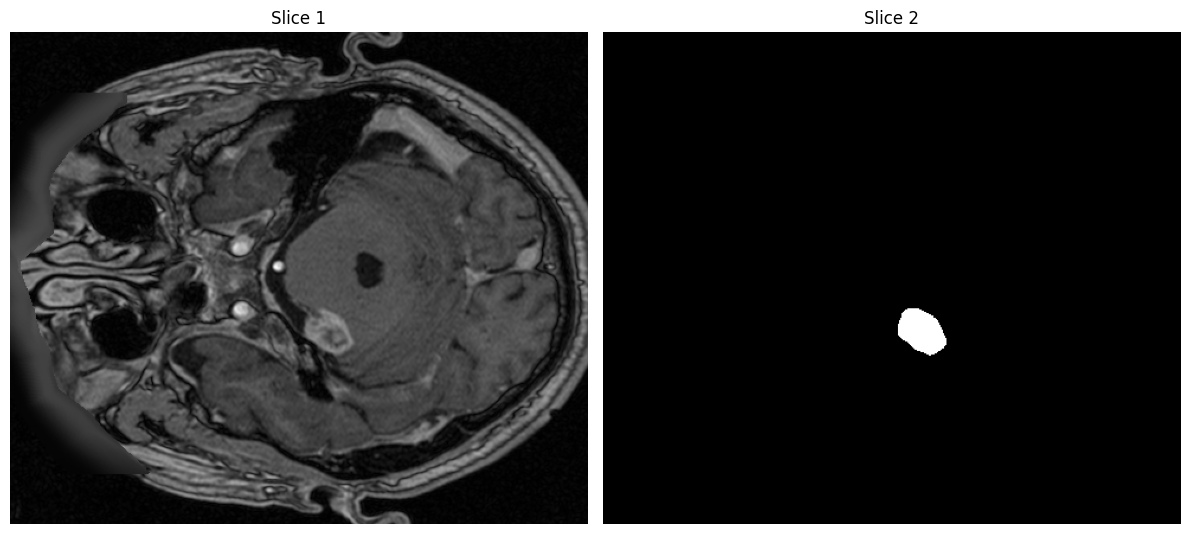

In [77]:
import matplotlib.pyplot as plt

# Select two slices from the data (you can adjust the indices)
file_path = "C:/example_input_images/ceT1/vs_gk_0000.nii.gz"
nii_img = nib.load(file_path)

# Get the data as a NumPy array
data1 = nii_img.get_fdata()


file_path = "C:/Users/Rishabh/Documents/nnUNet/output_folder/vs_gk.nii.gz"
nii_img = nib.load(file_path)

# Get the data as a NumPy array
data2 = nii_img.get_fdata()

slice_1 = data1[:, :, 25]  # First slice
slice_2 = data2[:, :, 25]  # Second slice

# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Plot the first slice
axes[0].imshow(slice_1, cmap="gray")
axes[0].set_title("Slice 1")
axes[0].axis("off")

# Plot the second slice
axes[1].imshow(slice_2, cmap="gray")
axes[1].set_title("Slice 2")
axes[1].axis("off")

# Show the plots
plt.tight_layout()  # Adjust spacing between the plots
plt.show()


In [75]:
data1.shape

(416, 488, 81)

In [76]:
81/3

27.0